In [1]:
from dataclasses import replace
from functools import partial
from typing import Tuple

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shapely.geometry as shap_geom
from shapely.prepared import prep
import sys
sys.path.insert(0, "/mount/moritadbjp/sharefilesjp/work/thickMOTO")

import moto.src.bc as _bc
import moto.src.geometry as _geom
import moto.src.material_points as _mp
import moto.src.mesher as _mesher
import moto.src.mma as _mma
import moto.src.thickness_constraint as _thickness
import moto.src.utils as _utils
import moto.src.viz as _viz
from moto.src.hyperelastic_mpm import HyperelasticMPM, StructField
from moto.src.material import StructuralMaterial
from moto.src.nl_solver import LinearSolvers
from moto.src.solve import newton_solve

_Ext = _utils.Extent

jax.config.update("jax_enable_x64", True)
GIF_DIR = "frames"
GIF_PATH = "mpm.gif"
GIF_FPS = 3
frames = []

_Field = StructField

/mount/moritadbjp/sharefilesjp/work/thickMOTO/moto/src/nl_solver.py:22: UserWarning: petsc4py library not found. PETSc solver is not available.
  warnings.warn("petsc4py library not found. PETSc solver is not available.")
/mount/moritadbjp/sharefilesjp/work/thickMOTO/moto/src/nl_solver.py:27: UserWarning: pypardiso library not found. Some solvers may not be available.
  warnings.warn("pypardiso library not found. Some solvers may not be available.")


## Geometry & Mesh

In [2]:
bbox = _geom.BrepGeometry("../brep/rect_domain_expt_1.json")
bar_bbox = _geom.BrepGeometry("../brep/cantilever_expt_1.json")
mesh = _mesher.grid_mesh_brep(
  brep=bbox,
  nelx_desired=80,
  nely_desired=40,
  dofs_per_node=2,
  gauss_order=2,
)

## Material Points Generation 


In [3]:
prepared_beam_geom = prep(bar_bbox.geometry)
inside = np.array(
  [prepared_beam_geom.covers(shap_geom.Point(xy)) for xy in mesh.elem_centers],
  dtype=bool,
)

# Element IDs to populate
occupied_element_ids = np.where(inside)[0]

# MPs
num_mp_per_elem_per_dim = 4
mp_coords = _mesher.generate_mp_coords_in_occupied_elements(
  mesh,
  occupied_element_ids,
  num_mp_per_elem_per_dim,
)
num_mat_pts = mp_coords.shape[0]

# Boundary conditions

In [4]:
face_tol = float(np.asarray(mesh.elem_size)[0]) * 0.5

left_faces = _bc.identify_faces(mesh, edges=[bar_bbox.edges[3]], tol=face_tol)
nL = len(left_faces)

left_clamped = _bc.DirichletBC(
  elem_faces=left_faces,
  values=[(_Field.U, np.zeros(nL)), (_Field.V, np.zeros(nL))],
  name="clamped-left",
)
bcs_list = [left_clamped]
bc = _bc.process_boundary_conditions(bcs_list, mesh)


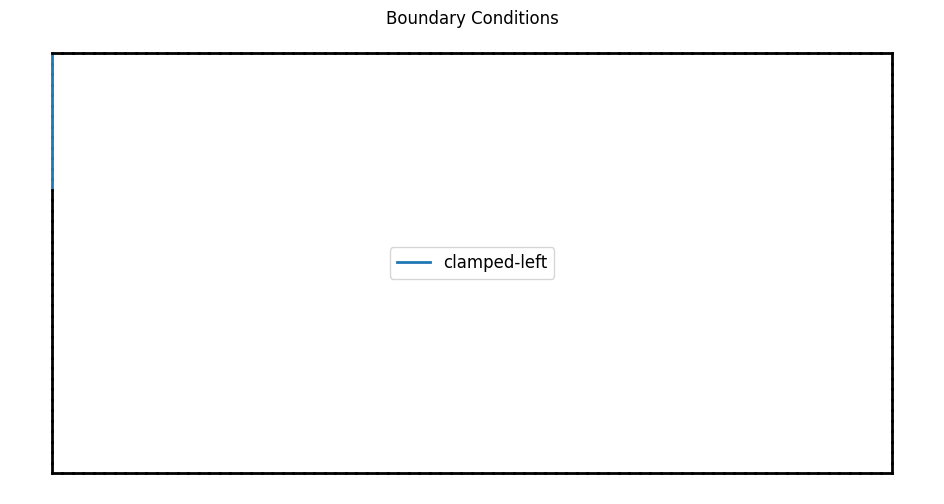

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
_viz.plot_grid_mesh(mesh, ax=ax, colorbar=False)
_viz.plot_bc(bcs_list, mesh, ax=ax)
plt.show()

## Material Initialization

In [6]:
mat = StructuralMaterial(
  youngs_modulus=3.0e9,  # 3.0 GPa
  poissons_ratio=0.4,
  mass_density=1600.0,
  yield_strength=20e4,
)

# MP half-lengths and volumes
thickness = 1e-3
elem_size = jnp.asarray(mesh.elem_size)
half_length_per_mp = elem_size / (2 * num_mp_per_elem_per_dim)
volume_per_mp = (
  thickness * jnp.prod(elem_size) / (num_mp_per_elem_per_dim**mesh.num_dim)
)

max_nodes = 3**mesh.num_dim
max_elems = 2**mesh.num_dim

mp_state, _ = _mp.initialize_new_material_points(
  num_pts=num_mat_pts,
  num_dim=mesh.num_dim,
  max_nodes_per_point=max_nodes,
  max_elems_per_point=max_elems,
)
mass_per_mp = volume_per_mp * mat.mass_density

mp_state = replace(
  mp_state,
  coord=mp_coords,
  volume=volume_per_mp * jnp.ones((num_mat_pts,), dtype=jnp.float64),
  volume0=volume_per_mp * jnp.ones((num_mat_pts,), dtype=jnp.float64),
  mass=mass_per_mp * jnp.ones((num_mat_pts,), dtype=jnp.float64),
  domain_length=jnp.tile(half_length_per_mp[None, :], (num_mat_pts, 1)),
  domain_length0=jnp.tile(half_length_per_mp[None, :], (num_mat_pts, 1)),
)

## Density filter

In [7]:
density_filter = _utils.create_density_filter(
  coords=mp_coords,
  cutoff_distance=1.5 * mesh.elem_size[0],
  filter_type=_utils.Filters.CIRCULAR,
)

thickness_params = _thickness.MaximumThicknessParams(
  diffusion=1e-4,
  h0=0.3,
  ramp_epsilon=0.0001,
  j_max=0.01,
  characteristic_width=0.025,
  reference_length=0.09,
  projection_volume_mode="reference",
)
thickness_characteristic_mode = "density"

thickness_precompute = _thickness.precompute_rect4_mesh(
  mesh, reference_length=thickness_params.reference_length
)

#  Forces on material points

In [8]:
# pick loaded material points by bbox
bar_mid = (bar_bbox.geometry.bounds[1] + bar_bbox.geometry.bounds[3]) / 2
bar_right = bar_bbox.geometry.bounds[2]
force_bbox = _mesher.BoundingBox(
  x=_Ext(min=bar_right - face_tol, max=bar_right + face_tol),
  y=_Ext(min=bar_mid - face_tol, max=bar_mid + face_tol),
)

mask = _mesher.compute_point_indices_in_box(np.asarray(mp_state.coord), force_bbox)
loaded_ids = np.where(np.asarray(mask))[0]
if loaded_ids.size == 0:
  raise ValueError(
    "No material points found in force_bbox; widen bbox or check coords."
  )

# distribute a total load across those MPs
F_total = -2.5e2  # total downward force (N)
f_per_mp = F_total / loaded_ids.size

mp_point_force = jnp.zeros((num_mat_pts, mesh.num_dim), dtype=jnp.float64)
mp_point_force = mp_point_force.at[loaded_ids, 1].set(f_per_mp)  # y-dir = 1

mp_state = replace(mp_state, point_force=mp_point_force)
print(f"Applied total force {F_total:.3e} N over {loaded_ids.size} material points.")


Applied total force -2.500e+02 N over 4 material points.


/tmp/ipykernel_54402/2353907320.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  img = ax.scatter(


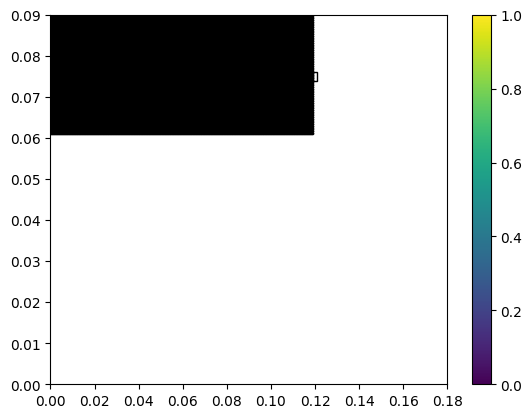

In [9]:
sigma_xy = mp_state.cauchy_stress[:, 3]

fig, ax = plt.subplots()
img = ax.scatter(
  mp_state.coord[:, 0],
  mp_state.coord[:, 1],
  s=2,
  c=sigma_xy,
  cmap="coolwarm",
)

for bbox in [force_bbox]:
  rect = plt.Rectangle(
    (float(bbox.x.min), float(bbox.y.min)),
    float(bbox.x.max - bbox.x.min),
    float(bbox.y.max - bbox.y.min),
    linewidth=1.0,
    edgecolor="black",
    facecolor="None",
  )
  ax.add_patch(rect)

ax.set_xlim([float(mesh.bounding_box.x.min), float(mesh.bounding_box.x.max)])
ax.set_ylim([float(mesh.bounding_box.y.min), float(mesh.bounding_box.y.max)])

plt.colorbar(img, ax=ax)
plt.show()
plt.pause(0.0001)

## Solver Setup

In [10]:
nr_tol, max_nr_iter = 1e-7, 50

solver_settings = {
  "linear": {"solver": LinearSolvers.SCIPY_SPARSE, "rtol": 1e-12},
  "nonlinear": {
    "max_iter": max_nr_iter,
    "threshold": nr_tol,
    "lam_min": 0.01,
    "line_search_max_iter": 12,
    "line_search_shrink": 0.5,
    "line_search_alpha_min": 1e-6,
    "line_search_armijo_c": 1e-4,
  },
}

mpm_problem = HyperelasticMPM(
  solver_settings=solver_settings,
  mesh=mesh,
)

du_guess = jnp.zeros((mesh.num_dofs,)) + 1e-3
du_guess = du_guess.at[bc["fixed_dofs"]].set(0.0)
gravity_vec = jnp.zeros((mesh.num_dim,))


In [11]:
num_load_steps = 15
eta = 0.5
rho_min = 1e-3


In [12]:
def _densities_from_design(
  x: jnp.ndarray,
  penal: float,
  beta: float,
) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray]:
  rho_tilde = (density_filter @ x.reshape(-1)).reshape(-1)
  rho_bar = _utils.threshold_filter(rho_tilde, beta=beta, eta=eta)
  rho_bar = jnp.clip(rho_bar, 0.0, 1.0)

  rho_E = rho_min + (1.0 - rho_min) * (rho_bar**penal)

  return rho_bar, rho_E, rho_tilde

In [13]:
@partial(jax.jit, static_argnames=("num_load_steps",))
def objective_function(
  density: jnp.ndarray,
  mp_state0: _mp.MaterialPointConfig,
  penal: float,
  thresh_beta: float,
  num_load_steps: int,
  gravity_vec: jnp.ndarray,
) -> Tuple[jnp.ndarray, jnp.ndarray, _mp.MaterialPointConfig, jnp.ndarray]:
  def obj(x_flat: jnp.ndarray):
    rho_bar, rho_E, _ = _densities_from_design(
      x_flat,
      penal=penal,
      beta=thresh_beta,
    )
    lam = mat.lame_parameters[0] * rho_E
    mu = mat.lame_parameters[1] * rho_E

    matpt_massdens = mat.mass_density * rho_E
    matpt_mass = matpt_massdens * mp_state0.volume0

    mp_state_in = replace(mp_state0, pseudo_density=rho_E, mass=matpt_mass)

    mp_final, _ = newton_solve(
      mesh=mesh,
      mp_state=mp_state_in,
      bc=bc,
      du_guess=du_guess,
      load_steps=num_load_steps,
      gravity=gravity_vec,
      mpm_problem=mpm_problem,
      lame_lambda=lam,
      lame_mu=mu,
      mp_point_force=mp_state_in.point_force,
    )

    obj = jnp.einsum("pd,pd->", mp_state_in.point_force, mp_final.displacement)

    return obj, (mp_final, rho_bar)

  (complaince, (mp_final, rho_bar)), d_complaince = jax.value_and_grad(
    obj, has_aux=True
  )(density.reshape(-1))
  return complaince, d_complaince.reshape((-1, 1)), mp_final, rho_bar


In [14]:
@partial(jax.jit, static_argnames=("max_vol_frac",))
def constraint_function(
  density: jnp.ndarray,
  mp_state0: _mp.MaterialPointConfig,
  max_vol_frac: float,
  penal: float,
  thresh_beta: float,
) -> Tuple[jnp.ndarray, jnp.ndarray]:
  init_vol = mp_state0.volume0.reshape(-1)
  total_init_vol = jnp.sum(init_vol)

  def constraint_wrapper(x_flat: jnp.ndarray) -> jnp.ndarray:
    rho_bar, _, _ = _densities_from_design(
      x_flat,
      penal=penal,
      beta=thresh_beta,
    )
    vol_frac = jnp.sum(rho_bar * init_vol) / total_init_vol
    return (vol_frac / max_vol_frac) - 1.0  # <= 0

  g, dg = jax.value_and_grad(constraint_wrapper)(density.reshape(-1))
  return jnp.array([g]), dg.reshape(1, -1)


def apply_density_operator(operator, values: np.ndarray) -> np.ndarray:
  try:
    return np.asarray(operator @ values, dtype=float).reshape(-1)
  except TypeError:
    return np.asarray(operator @ jnp.asarray(values), dtype=float).reshape(-1)


def evaluate_design_thickness_with_mode(
  design: np.ndarray,
  density_filter,
  threshold_beta: float,
  threshold_eta: float,
  projection: _thickness.NormalizedGIMPProjection,
  params: _thickness.MaximumThicknessParams,
  precompute: _thickness.Rect4Precompute,
  characteristic_mode: str,
):
  if characteristic_mode == "heaviside":
    return _thickness.evaluate_design_thickness(
      design=design,
      density_filter=density_filter,
      threshold_beta=threshold_beta,
      threshold_eta=threshold_eta,
      projection=projection,
      params=params,
      precompute=precompute,
    )
  if characteristic_mode != "density":
    raise ValueError(
      "thickness_characteristic_mode must be 'heaviside' or 'density'"
    )

  design_values = np.asarray(design, dtype=float).reshape(-1)
  rho_tilde = apply_density_operator(density_filter, design_values)
  denominator = np.tanh(threshold_beta * threshold_eta) + np.tanh(
    threshold_beta * (1.0 - threshold_eta)
  )
  shifted = threshold_beta * (rho_tilde - threshold_eta)
  rho_bar = (
    np.tanh(threshold_beta * threshold_eta) + np.tanh(shifted)
  ) / denominator
  threshold_derivative = (
    threshold_beta * (1.0 - np.tanh(shifted) ** 2) / denominator
  )

  phi_particles = 2.0 * (rho_bar - 0.5)
  phi_nodes = projection.apply(phi_particles, inactive_value=-1.0)
  characteristic = projection.apply(rho_bar, inactive_value=0.0)
  analysis = _thickness.analyze_maximum_thickness(
    characteristic, params, precompute
  )

  gradient_rho_bar = projection.transpose(analysis.gradient_characteristic)
  gradient_rho_tilde = gradient_rho_bar * threshold_derivative
  gradient_design = apply_density_operator(
    density_filter.T, gradient_rho_tilde
  )
  if not np.all(np.isfinite(gradient_design)):
    raise FloatingPointError("maximum-thickness design gradient is non-finite")

  return _thickness.DesignThicknessResult(
    rho_tilde=rho_tilde,
    rho_bar=rho_bar,
    phi_particles=phi_particles,
    phi_nodes=phi_nodes,
    analysis=analysis,
    gradient_design=gradient_design,
  )


def thickness_constraint_function(
  density: np.ndarray,
  thresh_beta: float,
  projection: _thickness.NormalizedGIMPProjection,
):
  result = evaluate_design_thickness_with_mode(
    design=np.asarray(density).reshape(-1),
    density_filter=density_filter,
    threshold_beta=thresh_beta,
    threshold_eta=eta,
    projection=projection,
    params=thickness_params,
    precompute=thickness_precompute,
    characteristic_mode=thickness_characteristic_mode,
  )
  constraint = np.array([[result.analysis.constraint]], dtype=np.float64)
  gradient = result.gradient_design.reshape(1, -1)
  return constraint, gradient, result


## Optimization

In [15]:
def optimize_design(
  mp_state0: _mp.MaterialPointConfig,
  max_vol_frac: float,
  max_iter: int,
  num_load_steps: int = 15,
  gravity_vec=None,
  move_limit: float = 1e-2,
  kkt_tol: float = 1e-7,
  step_tol: float = 1e-7,
  plot_interval: int = 2,
  projection_volume_mode: str = "reference",
  constraint_mode: str = "volume_and_thickness",
  thickness_start_epoch: int = 0,
):
  convg_history = {
    "epoch": [],
    "objective": [],
    "volfrac_cons": [],
    "thickness_cons": [],
  }
  if gravity_vec is None:
    gravity_vec = jnp.zeros((mesh.num_dim,), dtype=jnp.float64)
  if projection_volume_mode not in ("reference", "current"):
    raise ValueError("projection_volume_mode must be 'reference' or 'current'")
  if constraint_mode not in ("volume", "volume_and_thickness"):
    raise ValueError(
      "constraint_mode must be 'volume' or 'volume_and_thickness'"
    )

  obj_0 = 1.0
  num_design_var = int(mp_state0.coord.shape[0])
  reference_projection = _thickness.build_gimp_projection(
    mesh, mp_state0, mode="reference"
  )

  design_var = (max_vol_frac * np.ones((num_design_var, 1))).astype(np.float64)
  num_cons = 1 if constraint_mode == "volume" else 2

  lower_bound = np.zeros((num_design_var, 1))
  upper_bound = np.ones((num_design_var, 1))

  mma_params = _mma.MMAParams(
    max_iter=max_iter,
    kkt_tol=kkt_tol,
    step_tol=step_tol,
    move_limit=move_limit,
    num_design_var=num_design_var,
    num_cons=num_cons,
    lower_bound=lower_bound,
    upper_bound=upper_bound,
  )
  mma_state = _mma.init_mma(design_var, mma_params)
  thickness_result = None

  while mma_state.epoch < max_iter:
    print("mma_state.epoch", mma_state.epoch)

    penal = min(5.0, 1.0 + mma_state.epoch * 0.05)
    thresh_beta = min(32.0, 1.0 + 2.5 * mma_state.epoch)

    objective, grad_obj, mp_final, rho_phys = objective_function(
      mma_state.x, mp_state0, penal, thresh_beta, num_load_steps, gravity_vec
    )

    vol_constr, grad_vol = constraint_function(
      mma_state.x,
      mp_state0,
      max_vol_frac,
      penal=penal,
      thresh_beta=thresh_beta,
    )
    projection = reference_projection
    if projection_volume_mode == "current":
      projection = _thickness.build_gimp_projection(
        mesh, mp_state0, current_state=mp_final, mode="current"
      )
    thickness_constr, grad_thickness, thickness_result = (
      thickness_constraint_function(mma_state.x, thresh_beta, projection)
    )
    thickness_active = (
      constraint_mode == "volume_and_thickness"
      and mma_state.epoch >= thickness_start_epoch
    )
    constr = np.asarray(vol_constr).reshape(1, 1)
    grad_cons = np.asarray(grad_vol).reshape(1, -1)
    if constraint_mode == "volume_and_thickness":
      mma_thickness_constr = (
        thickness_constr
        if thickness_active
        else np.array([[-1.0]], dtype=np.float64)
      )
      mma_grad_thickness = (
        grad_thickness if thickness_active else np.zeros_like(grad_thickness)
      )
      constr = np.vstack((constr, mma_thickness_constr))
      grad_cons = np.vstack((grad_cons, mma_grad_thickness))
    assert constr.shape == (num_cons, 1)
    assert grad_cons.shape == (num_cons, num_design_var)
    assert np.all(np.isfinite(constr)) and np.all(np.isfinite(grad_cons))

    values = (
      mma_state.epoch,
      float(objective),
      float(constr[0, 0]),
      float(thickness_constr[0, 0]),
    )
    for key, value in zip(convg_history, values):
      convg_history[key].append(value)
    status = (
      f"epoch {mma_state.epoch} J {float(objective):.2E} "
      f"G_vol {constr[0, 0]:.3E} "
      f"G_thick {thickness_constr[0, 0]:.3E} mode={constraint_mode}"
    )
    print(status)

    if mma_state.epoch == 0 or mma_state.epoch == 10:
      obj_0 = jax.lax.stop_gradient(objective)

    if plot_interval > 0 and mma_state.epoch % plot_interval == 0:
      coords = np.asarray(mp_final.coord)
      node_coords = np.asarray(mesh.nodes.coords)
      fields = (
        (coords, np.asarray(rho_phys), "rho_bar", 0.0, 1.0),
        (
          node_coords,
          thickness_result.analysis.characteristic,
          "chi_node",
          0.0,
          1.0,
        ),
        (
          node_coords,
          np.clip(
            thickness_result.analysis.thickness,
            0.0,
            2.0 * thickness_params.h0,
          ),
          "thickness (clipped)",
          0.0,
          2.0 * thickness_params.h0,
        ),
        (
          node_coords,
          thickness_result.analysis.evaluation,
          "violation",
          0.0,
          None,
        ),
      )
      fig, axes = plt.subplots(1, 4, figsize=(16, 3), constrained_layout=True)
      for ax, (field_coords, values, title, vmin, vmax) in zip(axes, fields):
        image = ax.scatter(
          field_coords[:, 0],
          field_coords[:, 1],
          s=2,
          c=values,
          cmap="viridis",
          vmin=vmin,
          vmax=vmax,
        )
        ax.set_aspect("equal")
        ax.set_title(title)
        fig.colorbar(image, ax=ax, shrink=0.75)
      plt.show()
      plt.pause(1e-6)

    mma_state, constraint_multipliers = _mma.update_mma(
      mma_state,
      mma_params,
      objective / obj_0,
      grad_obj / obj_0,
      constr,
      grad_cons,
      return_multipliers=True,
    )

    weights = np.asarray(mp_state0.volume0).reshape(-1)
    effective_comp = np.asarray(grad_obj / obj_0).reshape(-1)
    lambda_thick = (
      float(constraint_multipliers[1, 0])
      if thickness_active
      else 0.0
    )
    effective_thick = (
      lambda_thick * np.asarray(grad_thickness).reshape(-1)
    )
    s_comp = float(np.dot(weights, np.abs(effective_comp)) / np.sum(weights))
    s_thick = float(np.dot(weights, np.abs(effective_thick)) / np.sum(weights))
    cosine_denominator = np.sqrt(
      np.dot(weights, effective_comp**2)
      * np.dot(weights, effective_thick**2)
    )
    cosine = (
      float(np.dot(weights, effective_comp * effective_thick) / cosine_denominator)
      if cosine_denominator > 0.0
      else np.nan
    )
    print(
      f"S_comp={s_comp:.3e} S_thick={s_thick:.3e} cos={cosine:.3f}"
    )

  convg_history["final_sensitivities"] = (
    np.asarray(grad_obj / obj_0).reshape(-1),
    float(constraint_multipliers[0, 0]) * np.asarray(grad_vol).reshape(-1),
    effective_thick.copy(),
  )
  convg_history["final_raw_thickness_sensitivity"] = (
    np.asarray(grad_thickness).reshape(-1).copy()
  )
  convg_history["final_raw_compliance_sensitivity"] = (
    np.asarray(grad_obj).reshape(-1).copy()
  )

  return mma_state, mp_final, rho_phys, thickness_result, convg_history


mma_state.epoch 0
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 2.2956000651916267e-09
step 1/1
epoch 0 J 1.04E+01 G_vol -1.532E-14 G_thick 1.998E-01 mode=volume_and_thickness


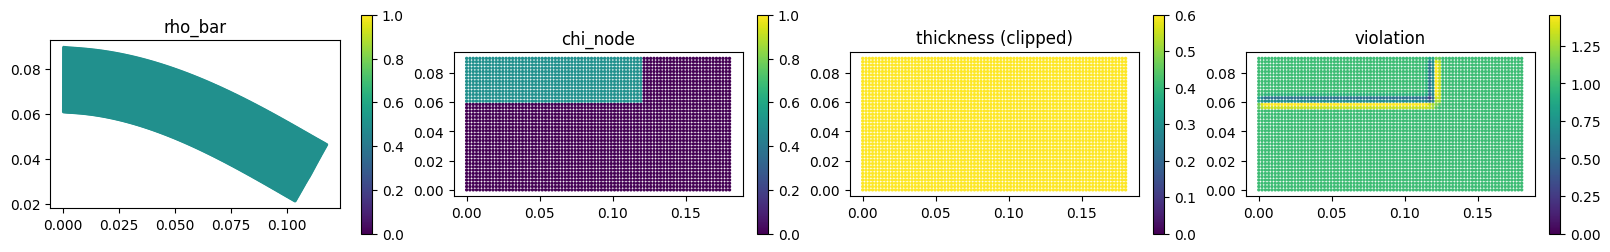

S_comp=1.589e-04 S_thick=3.705e-02 cos=-0.536
mma_state.epoch 1
step 1/1
NR converged in 10 iters, res_norm/res_norm_0: 1.2055381215401332e-08
step 1/1
epoch 1 J 1.07E+01 G_vol -6.622E-04 G_thick 1.996E-01 mode=volume_and_thickness
S_comp=2.915e-04 S_thick=6.366e-02 cos=-0.536
mma_state.epoch 2
step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 7.151161712391227e-13
step 1/1
epoch 2 J 1.11E+01 G_vol -2.870E-03 G_thick 1.992E-01 mode=volume_and_thickness


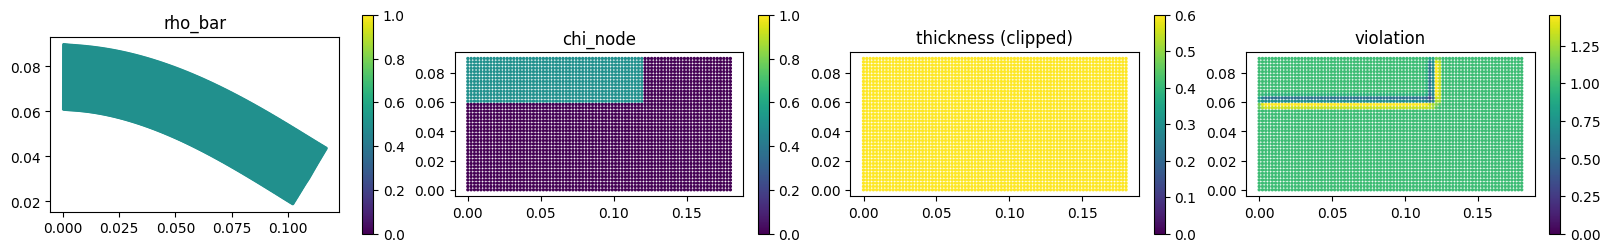

S_comp=5.041e-04 S_thick=1.033e-01 cos=-0.535
mma_state.epoch 3
step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 5.428157883159027e-11
step 1/1
epoch 3 J 1.14E+01 G_vol -8.795E-03 G_thick 1.980E-01 mode=volume_and_thickness
S_comp=7.596e-04 S_thick=1.458e-01 cos=-0.535
mma_state.epoch 4
step 1/1
NR converged in 11 iters, res_norm/res_norm_0: 1.8959586768416743e-09
step 1/1
epoch 4 J 1.19E+01 G_vol -2.138E-02 G_thick 1.954E-01 mode=volume_and_thickness


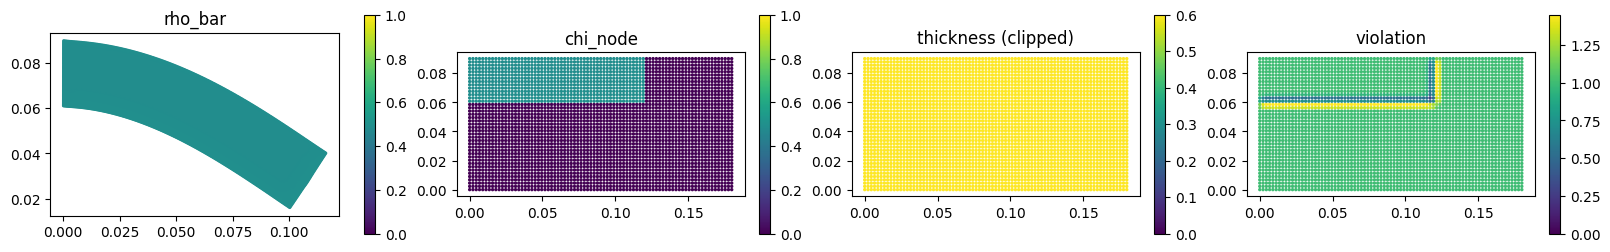

S_comp=1.056e-03 S_thick=1.889e-01 cos=-0.535
mma_state.epoch 5
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 2.4270190837786483e-12
step 1/1
epoch 5 J 1.24E+01 G_vol -4.462E-02 G_thick 1.907E-01 mode=volume_and_thickness
S_comp=1.408e-03 S_thick=2.322e-01 cos=-0.535
mma_state.epoch 6
step 1/1
NR converged in 12 iters, res_norm/res_norm_0: 1.3593111753317403e-08
step 1/1
epoch 6 J 1.33E+01 G_vol -8.377E-02 G_thick 1.828E-01 mode=volume_and_thickness


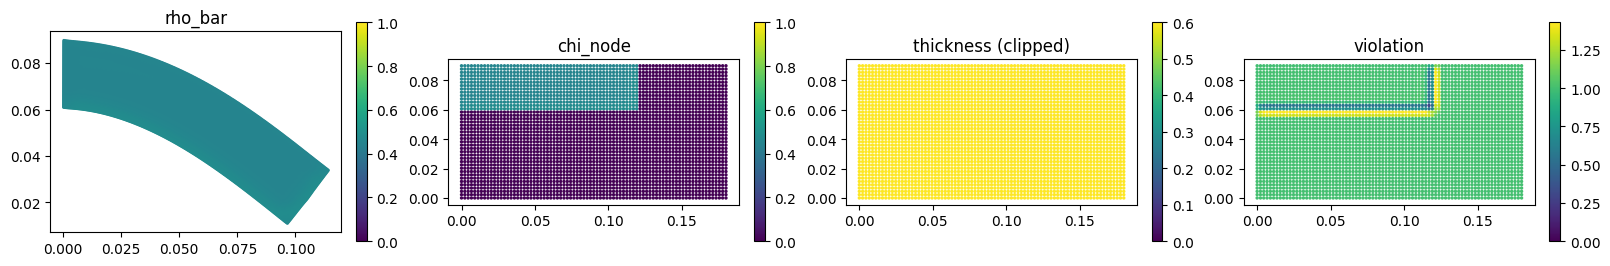

S_comp=1.840e-03 S_thick=2.753e-01 cos=-0.534
mma_state.epoch 7
step 1/1
NR converged in 14 iters, res_norm/res_norm_0: 3.6663234710852597e-13
step 1/1
epoch 7 J 1.45E+01 G_vol -1.454E-01 G_thick 1.703E-01 mode=volume_and_thickness
S_comp=2.383e-03 S_thick=3.161e-01 cos=-0.533
mma_state.epoch 8
step 1/1
NR converged in 15 iters, res_norm/res_norm_0: 5.766124432488219e-09
step 1/1
epoch 8 J 1.64E+01 G_vol -2.363E-01 G_thick 1.517E-01 mode=volume_and_thickness


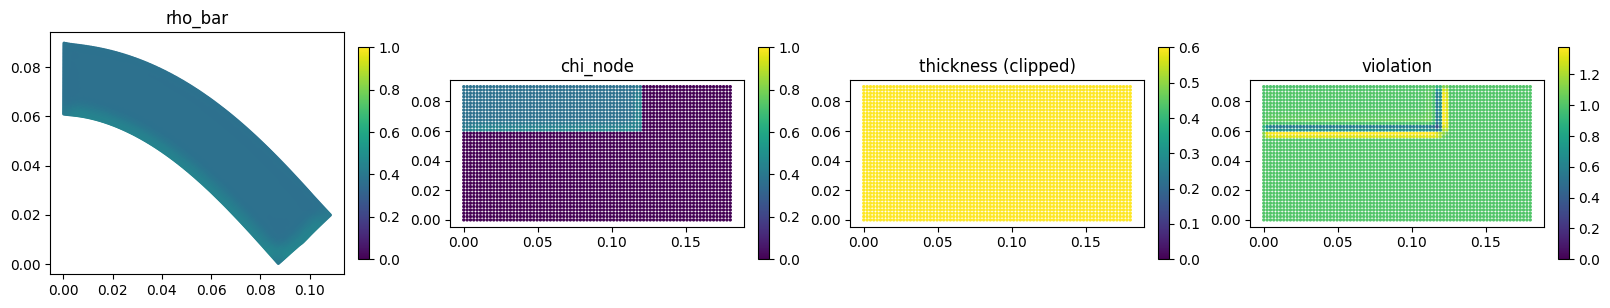

S_comp=3.049e-03 S_thick=3.492e-01 cos=-0.530
mma_state.epoch 9
step 1/1
NR converged in 17 iters, res_norm/res_norm_0: 3.79548042380374e-12
step 1/1
epoch 9 J 1.92E+01 G_vol -3.601E-01 G_thick 1.263E-01 mode=volume_and_thickness
S_comp=3.733e-03 S_thick=3.633e-01 cos=-0.519


In [16]:
mma_state, mp_final, rho_phys, thickness_result, convg_history = optimize_design(
  mp_state0=mp_state,
  max_vol_frac=0.5,
  max_iter=10,
  move_limit=1e-2,
  num_load_steps=1,
  gravity_vec=gravity_vec,
  projection_volume_mode=thickness_params.projection_volume_mode,
  constraint_mode="volume_and_thickness", #volume_and_thickness 
  thickness_start_epoch=0,
)

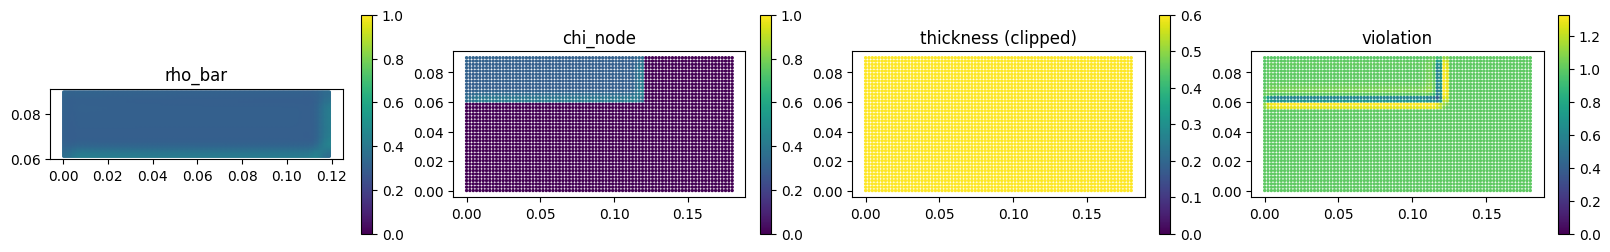

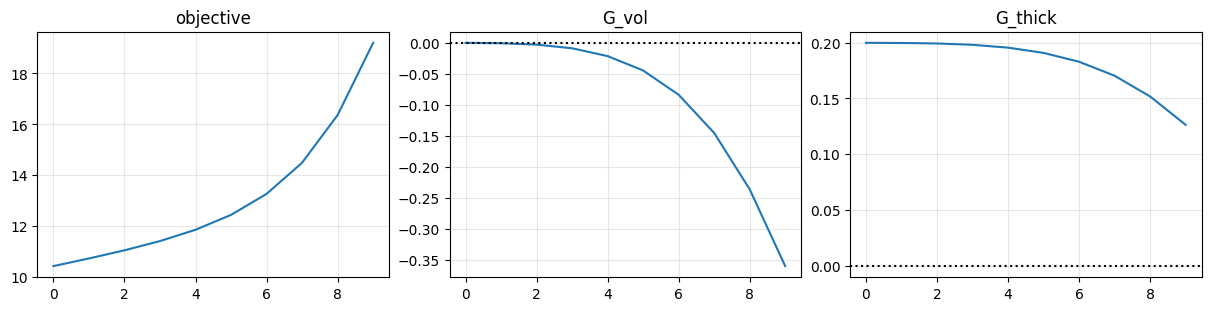

final feasibility: G_vol=-3.601E-01, G_thick=1.263E-01
1e-4 criterion: False


In [17]:
# plt.rcParams.update(_viz.high_res_plot_settings)

coords = np.asarray(mp_coords)
rho_np = np.asarray(rho_phys)

node_coords = np.asarray(mesh.nodes.coords)
final_fields = (
  (coords, rho_np, "rho_bar", 0.0, 1.0),
  (
    node_coords,
    thickness_result.analysis.characteristic,
    "chi_node",
    0.0,
    1.0,
  ),
  (
    node_coords,
    np.clip(
      thickness_result.analysis.thickness,
      0.0,
      2.0 * thickness_params.h0,
    ),
    "thickness (clipped)",
    0.0,
    2.0 * thickness_params.h0,
  ),
  (
    node_coords,
    thickness_result.analysis.evaluation,
    "violation",
    0.0,
    None,
  ),
)
fig, axes = plt.subplots(1, 4, figsize=(16, 3), constrained_layout=True)
for ax, (field_coords, values, title, vmin, vmax) in zip(axes, final_fields):
  image = ax.scatter(
    field_coords[:, 0],
    field_coords[:, 1],
    s=2,
    c=values,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
  )
  ax.set_aspect("equal")
  ax.set_title(title)
  fig.colorbar(image, ax=ax, shrink=0.75)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)
axes[0].plot(convg_history["epoch"], convg_history["objective"])
axes[0].set_title("objective")
axes[1].plot(convg_history["epoch"], convg_history["volfrac_cons"])
axes[1].axhline(0.0, color="black", linestyle=":")
axes[1].set_title("G_vol")
axes[2].plot(convg_history["epoch"], convg_history["thickness_cons"])
axes[2].axhline(0.0, color="black", linestyle=":")
axes[2].set_title("G_thick")
for ax in axes:
  ax.grid(True, alpha=0.3)
plt.show()

g_vol_final = convg_history["volfrac_cons"][-1]
g_thick_final = convg_history["thickness_cons"][-1]
print(f"final feasibility: G_vol={g_vol_final:.3E}, G_thick={g_thick_final:.3E}")
print(f"1e-4 criterion: {g_vol_final <= 1e-4 and g_thick_final <= 1e-4}")

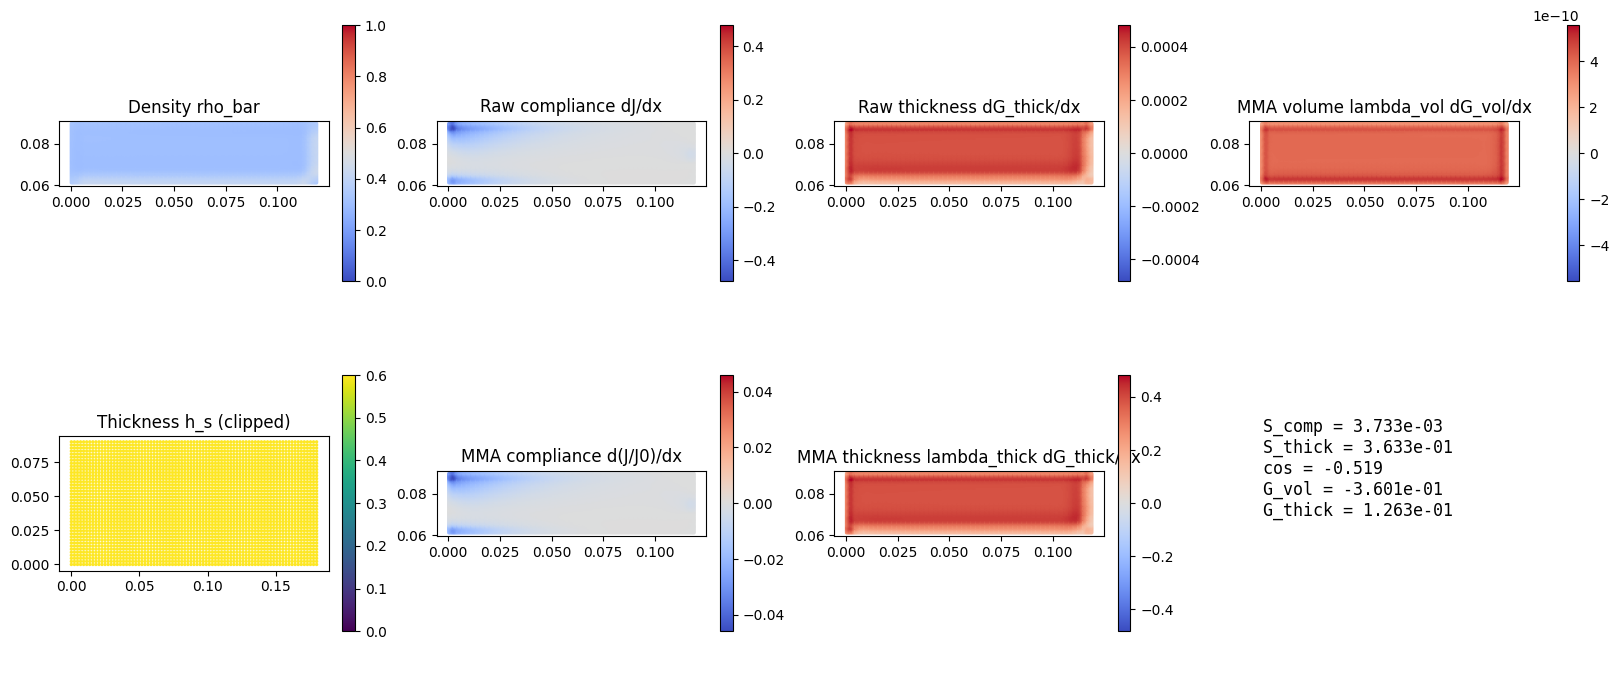

In [18]:
coords = np.asarray(mp_state.coord)
node_coords = np.asarray(mesh.nodes.coords)

effective_comp, effective_vol, effective_thick = (
  convg_history["final_sensitivities"]
)
raw_comp = convg_history["final_raw_compliance_sensitivity"]
raw_thickness = convg_history["final_raw_thickness_sensitivity"]
rho_bar = np.asarray(rho_phys).reshape(-1)
h_s = np.asarray(thickness_result.analysis.thickness)
h_s_clipped = np.clip(h_s, 0.0, 2.0 * thickness_params.h0)

weights = np.asarray(mp_state.volume0).reshape(-1)
s_comp = np.dot(weights, np.abs(effective_comp)) / np.sum(weights)
s_thick = np.dot(weights, np.abs(effective_thick)) / np.sum(weights)
cosine_denominator = np.sqrt(
  np.dot(weights, effective_comp**2)
  * np.dot(weights, effective_thick**2)
)
cosine = (
  np.dot(weights, effective_comp * effective_thick) / cosine_denominator
  if cosine_denominator > 0.0
  else np.nan
)

fig, axes = plt.subplots(2, 4, figsize=(16, 7), constrained_layout=True)

def plot_field(
  ax, field_coords, values, title, cmap="coolwarm", vmin=None, vmax=None
):
  image = ax.scatter(
    field_coords[:, 0],
    field_coords[:, 1],
    c=values,
    s=2,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
  )
  ax.set_aspect("equal")
  ax.set_title(title)
  fig.colorbar(image, ax=ax, shrink=0.75)

plot_field(
  axes[0, 0], coords, rho_bar, "Density rho_bar",
  cmap="coolwarm", vmin=0.0, vmax=1.0,
)
plot_field(
  axes[1, 0], node_coords, h_s_clipped, "Thickness h_s (clipped)",
  cmap="viridis", vmin=0.0, vmax=2.0 * thickness_params.h0,
)

for ax, values, title in (
  (axes[0, 1], raw_comp, "Raw compliance dJ/dx"),
  (axes[1, 1], effective_comp, "MMA compliance d(J/J0)/dx"),
  (axes[0, 2], raw_thickness, "Raw thickness dG_thick/dx"),
  (
    axes[1, 2],
    effective_thick,
    "MMA thickness lambda_thick dG_thick/dx",
  ),
  (axes[0, 3], effective_vol, "MMA volume lambda_vol dG_vol/dx"),
):
  limit = max(float(np.max(np.abs(values))), 1e-16)
  plot_field(ax, coords, values, title, vmin=-limit, vmax=limit)

axes[1, 3].axis("off")
axes[1, 3].text(
  0.05,
  0.75,
  (
    f"S_comp = {s_comp:.3e}\n"
    f"S_thick = {s_thick:.3e}\n"
    f"cos = {cosine:.3f}\n"
    f"G_vol = {convg_history['volfrac_cons'][-1]:.3e}\n"
    f"G_thick = {convg_history['thickness_cons'][-1]:.3e}"
  ),
  transform=axes[1, 3].transAxes,
  va="top",
  fontsize=12,
  family="monospace",
)
plt.show()

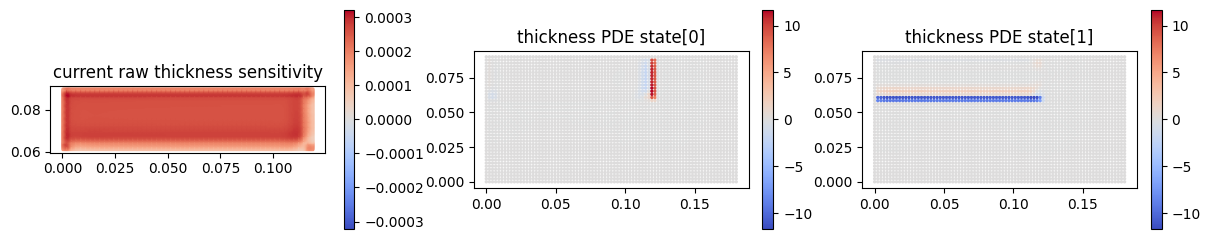

current G_thick=1.358e-01


In [19]:
current_beta = min(32.0, 1.0 + 2.5 * mma_state.epoch)
current_beta = 15

current_projection = _thickness.build_gimp_projection(
  mesh,
  mp_state,
  mode="reference",
)

(
  current_g_thick,
  current_grad_thickness,
  current_thickness_result,
) = thickness_constraint_function(
  mma_state.x,
  current_beta,
  current_projection,
)

current_grad_thickness = current_grad_thickness.reshape(-1)
current_states = np.asarray(current_thickness_result.analysis.states)
node_coords = np.asarray(mesh.nodes.coords)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)


def plot_current_field(ax, field_coords, values, title):
  limit = max(float(np.max(np.abs(values))), 1e-16)
  image = ax.scatter(
    field_coords[:, 0],
    field_coords[:, 1],
    c=values,
    s=2,
    cmap="coolwarm",
    vmin=-limit,
    vmax=limit,
  )
  ax.set_aspect("equal")
  ax.set_title(title)
  fig.colorbar(image, ax=ax, shrink=0.75)


plot_current_field(
  axes[0],
  np.asarray(mp_state.coord),
  current_grad_thickness,
  "current raw thickness sensitivity",
)
plot_current_field(
  axes[1],
  node_coords,
  current_states[0],
  "thickness PDE state[0]",
)
plot_current_field(
  axes[2],
  node_coords,
  current_states[1],
  "thickness PDE state[1]",
)

plt.show()

print(f"current G_thick={float(current_g_thick[0, 0]):.3e}")


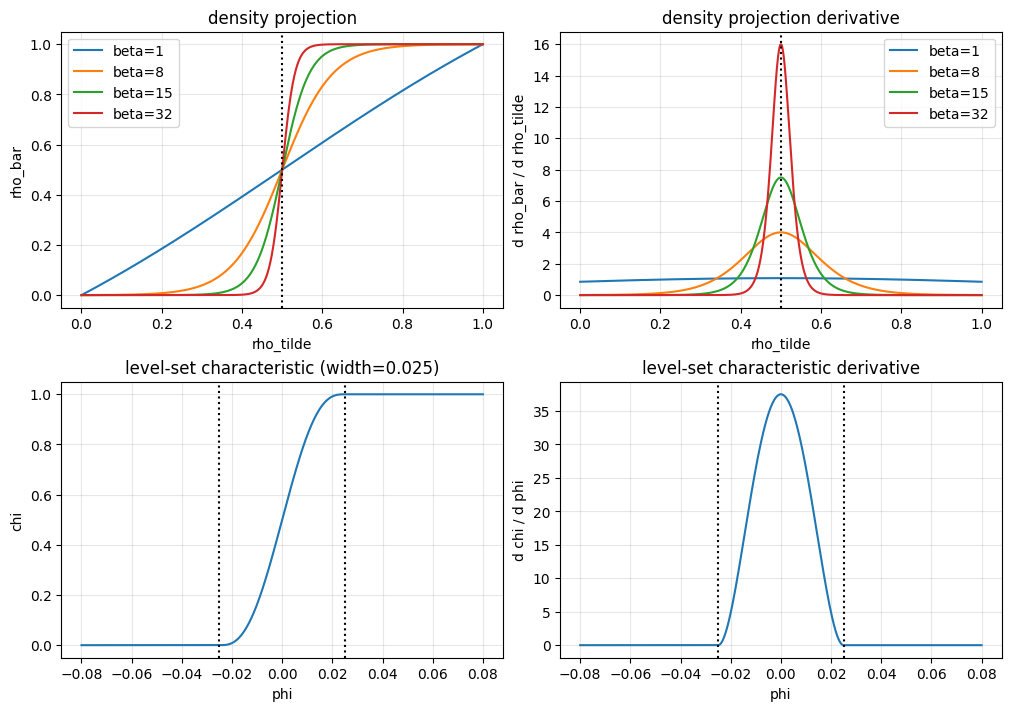

In [20]:
rho_tilde_plot = np.linspace(0.0, 1.0, 1001)
eta_plot = eta
beta_values = tuple(dict.fromkeys((1.0, 8.0, current_beta, 32.0)))

phi_plot = np.linspace(-0.08, 0.08, 1001)
width = thickness_params.characteristic_width
chi_plot = _thickness.smooth_characteristic(phi_plot, width=width)
dchi_plot = _thickness.smooth_characteristic_derivative(
  phi_plot, width=width
)

fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)
for beta in beta_values:
  denominator = np.tanh(beta * eta_plot) + np.tanh(
    beta * (1.0 - eta_plot)
  )
  shifted = beta * (rho_tilde_plot - eta_plot)
  rho_bar_plot = (
    np.tanh(beta * eta_plot) + np.tanh(shifted)
  ) / denominator
  drho_bar_plot = beta * (1.0 - np.tanh(shifted) ** 2) / denominator
  axes[0, 0].plot(rho_tilde_plot, rho_bar_plot, label=f"beta={beta:g}")
  axes[0, 1].plot(rho_tilde_plot, drho_bar_plot, label=f"beta={beta:g}")

axes[0, 0].axvline(eta_plot, color="black", linestyle=":")
axes[0, 0].set_title("density projection")
axes[0, 0].set_xlabel("rho_tilde")
axes[0, 0].set_ylabel("rho_bar")
axes[0, 0].legend()

axes[0, 1].axvline(eta_plot, color="black", linestyle=":")
axes[0, 1].set_title("density projection derivative")
axes[0, 1].set_xlabel("rho_tilde")
axes[0, 1].set_ylabel("d rho_bar / d rho_tilde")
axes[0, 1].legend()

axes[1, 0].plot(phi_plot, chi_plot)
axes[1, 0].axvline(-width, color="black", linestyle=":")
axes[1, 0].axvline(width, color="black", linestyle=":")
axes[1, 0].set_title(f"level-set characteristic (width={width:g})")
axes[1, 0].set_xlabel("phi")
axes[1, 0].set_ylabel("chi")

axes[1, 1].plot(phi_plot, dchi_plot)
axes[1, 1].axvline(-width, color="black", linestyle=":")
axes[1, 1].axvline(width, color="black", linestyle=":")
axes[1, 1].set_title("level-set characteristic derivative")
axes[1, 1].set_xlabel("phi")
axes[1, 1].set_ylabel("d chi / d phi")

for ax in axes.ravel():
  ax.grid(True, alpha=0.3)
plt.show()